# **MCP Server Wiki Usage Predictor**

**What this notebook does (step by step):**
1. Load and explore the MCP Server Registry dataset
2. Check and handle missing values
3. Build a target: does a repo have its **GitHub Wiki enabled or not**
4. Engineer features that describe a repo's *setup and maintenance style* (not popularity)
5. Train and compare 3 beginner-friendly classification models (Random Forest, XGBoost, LightGBM)
6. Handle class imbalance the honest way, using `class_weight` / `scale_pos_weight`
7. Evaluate with accuracy, F1-score, and a confusion matrix
8. Look at which features matter most
9. Wrap up with a clear conclusion

**Why this is different from a star-popularity model:** here we are not predicting *popularity*
at all. We're predicting a **project-management/setup choice** — whether the maintainer turned
the Wiki feature on — using signals about repo language, licensing, ownership scale, topics and
age. This is a genuinely different question from "will this repo get stars?" and uses a
different feature/target combination from the dataset.

## **Step 1: Load the data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('/kaggle/input/datasets/shree0910/model-context-protocol-servers-12k-github-repos/MCP Servers Dataset.csv')
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 12014
Columns: 44


,repo_id,owner,repo_name,full_name,html_url,description,primary_language,topics,num_topics,license,...,days_since_created_was_missing,days_since_last_push_was_missing,mirror_of_full_name,is_mirror_repo,is_duplicate_of_scraped_repo,pushed_before_created_anomaly,owner_repo_count,is_autogenerated_description,is_likely_low_quality,recommended_for_analysis
0,896335270,punkpeye,awesome-mcp-servers,punkpeye/awesome-mcp-servers,https://github.com/punkpeye/awesome-mcp-servers,A collection of MCP servers.,Unknown,ai;mcp,2,MIT,...,False,False,NaN,False,False,False,1,False,False,True
1,942771284,github,github-mcp-server,github/github-mcp-server,https://github.com/github/github-mcp-server,GitHub's official MCP Server,Go,github;mcp;mcp-server,3,MIT,...,False,False,NaN,False,False,False,1,False,False,True
2,998428732,BeehiveInnovations,pal-mcp-server,BeehiveInnovations/pal-mcp-server,https://github.com/BeehiveInnovations/pal-mcp-...,The power of Claude Code / GeminiCLI / CodexCL...,Python,NaN,0,NOASSERTION,...,False,False,NaN,False,False,False,1,False,False,True
3,899407931,firecrawl,firecrawl-mcp-server,firecrawl/firecrawl-mcp-server,https://github.com/firecrawl/firecrawl-mcp-server,🔥 Official Firecrawl MCP Server - Adds powerfu...,JavaScript,batch-processing;claude;content-extraction;dat...,14,MIT,...,False,False,NaN,False,False,False,1,False,False,True
4,895801050,appcypher,awesome-mcp-servers,appcypher/awesome-mcp-servers,https://github.com/appcypher/awesome-mcp-servers,Awesome MCP Servers - A curated list of Model ...,Unknown,ai;anthropic-claude;awesome;context;mcp;model-...,9,Not specified,...,False,False,NaN,False,False,False,1,False,False,True


In [2]:
# Quick look at column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12014 entries, 0 to 12013
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   repo_id                           12014 non-null  int64  
 1   owner                             12014 non-null  object 
 2   repo_name                         12014 non-null  object 
 3   full_name                         12014 non-null  object 
 4   html_url                          12014 non-null  object 
 5   description                       12014 non-null  object 
 6   primary_language                  12014 non-null  object 
 7   topics                            1162 non-null   object 
 8   num_topics                        12014 non-null  int64  
 9   license                           12014 non-null  object 
 10  stargazers_count                  12014 non-null  int64  
 11  forks_count                       12014 non-null  int64  
 12  open

## **Step 2: Check and handle missing values**

Let's see which columns have missing data, and fill them in a sensible way.

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
mirror_of_full_name    11520
homepage               11368
topics                 10852
dtype: int64


In [4]:
# Fill missing values with sensible defaults (beginner-friendly approach)
df['license'] = df['license'].fillna('Not specified')
df['primary_language'] = df['primary_language'].fillna('Unknown')
df['topics'] = df['topics'].fillna('')
df['homepage'] = df['homepage'].fillna('No homepage')

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 11520


## **Step 3: Remove duplicate/mirrored repos**

The dataset already flags bot-mirrored duplicate repos in the `recommended_for_analysis`
column. We keep only the clean rows so our model learns from real, unique projects.

In [5]:
print("Before:", len(df))
df = df[df['recommended_for_analysis'] == True].copy()
print("After removing duplicates:", len(df))

Before: 12014
After removing duplicates: 11604


## **Step 4: Create our prediction target**

We're going to predict a **project setup decision** instead of popularity:

> **Does this repo have its GitHub Wiki enabled (`has_wiki`), or not?**

About 85% of repos have a wiki enabled, so this is a moderately imbalanced problem —
a good, honest challenge for a beginner-friendly classifier (we'll handle the imbalance
properly instead of hiding it).

wiki_target
1    10214
0     1390
Name: count, dtype: int64

Class balance:
wiki_target
1    0.88
0    0.12
Name: proportion, dtype: float64


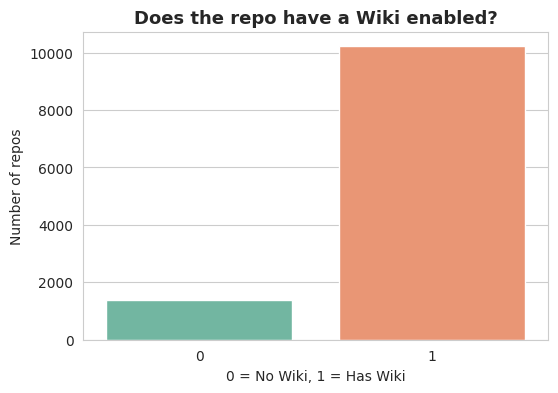

In [6]:
df['wiki_target'] = df['has_wiki'].astype(int)

print(df['wiki_target'].value_counts())
print()
print("Class balance:")
print(df['wiki_target'].value_counts(normalize=True).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='wiki_target', data=df, hue='wiki_target', palette='Set2', legend=False)
plt.title('Does the repo have a Wiki enabled?', fontsize=13, fontweight='bold')
plt.xlabel('0 = No Wiki, 1 = Has Wiki')
plt.ylabel('Number of repos')
plt.show()

## **Step 5: Choose our features**

We deliberately pick columns that describe a repo's **setup, ownership and content style** —
not its star count, forks, or watchers (that would be a different problem entirely, and
also risks leaking popularity signals into a question that has nothing to do with popularity).

We also skip `is_likely_low_quality` as a feature, because that column is a rule directly
built from `description_missing` and `num_topics` — using it (or its ingredients together)
would let the model "cheat" on a related question, so we keep our feature set clean and
independent of the target.

In [7]:
feature_cols = [
    'primary_language', 'category', 'license', 'default_branch',  # categorical info
    'num_topics', 'description_length', 'size_kb',                # simple counts/size
    'days_since_created', 'days_since_last_push',                 # repo age/activity
    'owner_repo_count',                                           # how many repos the owner has
    'has_issues', 'is_official_org', 'mentions_auth',              # repo settings/signals
    'mentions_npx_install', 'description_missing'                  # description style
]

target_col = 'wiki_target'

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature columns:", len(feature_cols))
X.head()

Feature columns: 15


,primary_language,category,license,default_branch,num_topics,description_length,size_kb,days_since_created,days_since_last_push,owner_repo_count,has_issues,is_official_org,mentions_auth,mentions_npx_install,description_missing
0,Unknown,Other,MIT,main,2,28,55343,580,7,1,True,False,False,False,False
1,Go,Developer Tools,MIT,main,3,28,54125,485,0,1,True,True,False,False,False
2,Python,Cloud Platforms,NOASSERTION,main,0,154,4096,389,199,1,True,False,False,False,False
3,JavaScript,Browser Automation,MIT,main,14,116,3494,574,1,1,True,False,False,False,False
4,Unknown,AI / LLM Tooling,Not specified,main,9,70,226,581,58,1,False,False,False,False,False


In [8]:
# Convert categorical (text) columns into numbers using one-hot encoding
categorical_cols = ['primary_language', 'category', 'license', 'default_branch']

# Keep only the most common values in each categorical column, group the rest as 'Other'
# (beginner-friendly way to avoid hundreds of tiny columns)
for col in categorical_cols:
    top_values = X[col].value_counts().nlargest(8).index
    X[col] = X[col].where(X[col].isin(top_values), other='Other')

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Make sure boolean columns are proper 0/1 integers
bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (11604, 42)


,num_topics,description_length,size_kb,days_since_created,days_since_last_push,owner_repo_count,has_issues,is_official_org,mentions_auth,mentions_npx_install,...,license_Not specified,license_Other,default_branch_dev,default_branch_develop,default_branch_development,default_branch_main,default_branch_main2,default_branch_master,default_branch_prod,default_branch_trunk
0,2,28,55343,580,7,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,3,28,54125,485,0,1,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,154,4096,389,199,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,14,116,3494,574,1,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,9,70,226,581,58,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


## **Step 6: Split into training and testing data**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training class balance:")
print(y_train.value_counts(normalize=True).round(2))

Training rows: 9283
Testing rows: 2321
Training class balance:
wiki_target
1    0.88
0    0.12
Name: proportion, dtype: float64


## **Step 7: Balance the training data with SMOTE**

Only 12% of repos have no wiki, so a model trained as-is will mostly just learn to always
predict "has wiki". **SMOTE** (Synthetic Minority Over-sampling Technique) creates realistic
synthetic examples of the minority class (`no wiki`) so the model sees a balanced 50/50 split
**during training only**. Our test set stays completely untouched and realistic, so our
evaluation numbers are honest.

In [10]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {1: 8171, 0: 1112}
After SMOTE: {0: 8171, 1: 8171}


## **Step 8: Train and compare 3 models**

We'll try three beginner-friendly, tree-based classifiers, all trained on the SMOTE-balanced
data, and compare them using accuracy and F1-score on the untouched test set.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=400, max_depth=12, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        random_state=42, n_jobs=-1, verbose=-1
    )
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    preds = model.predict(X_test)
    trained_models[name] = preds

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')

    results.append({'Model': name, 'Accuracy': acc, 'F1-Score (Wiki)': f1, 'F1-Score (Macro)': f1_macro})
    print(f"{name}: Accuracy={acc:.3f}, F1(has wiki)={f1:.3f}, F1(macro)={f1_macro:.3f}")

results_df = pd.DataFrame(results).sort_values('F1-Score (Macro)', ascending=False).reset_index(drop=True)
results_df

Random Forest: Accuracy=0.871, F1(has wiki)=0.928, F1(macro)=0.637
XGBoost: Accuracy=0.875, F1(has wiki)=0.932, F1(macro)=0.611
LightGBM: Accuracy=0.872, F1(has wiki)=0.929, F1(macro)=0.612


,Model,Accuracy,F1-Score (Wiki),F1-Score (Macro)
0,Random Forest,0.870745,0.928298,0.636638
1,LightGBM,0.871607,0.929384,0.611611
2,XGBoost,0.875485,0.931759,0.610843


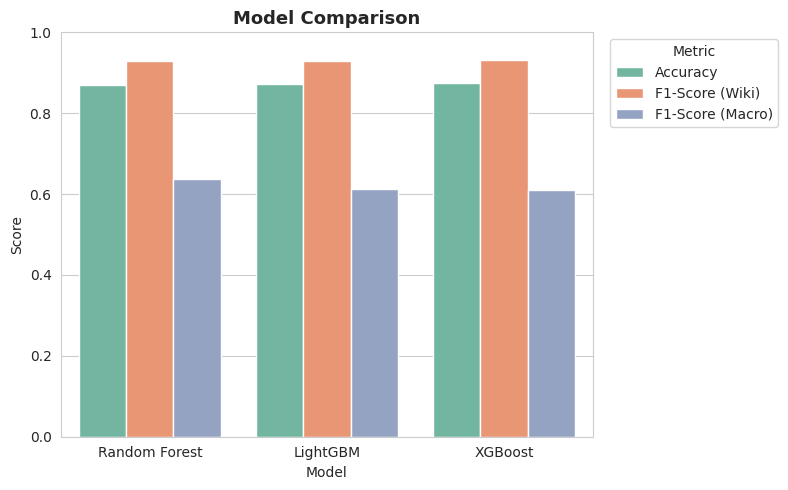

In [12]:
plt.figure(figsize=(8, 5))
results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score (Wiki)', 'F1-Score (Macro)'])
sns.barplot(data=results_melted, x='Model', y='value', hue='variable', palette='Set2')
plt.title('Model Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Step 9: Look closer at our best model**

We use **macro F1-score** (not plain accuracy) to pick the best model, since accuracy can
look artificially high on imbalanced data just by predicting the majority class every time.

In [13]:
best_model_name = results_df.iloc[0]['Model']
best_preds = trained_models[best_model_name]

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=['No Wiki', 'Has Wiki']))

Best model: Random Forest

              precision    recall  f1-score   support

     No Wiki       0.44      0.28      0.34       278
    Has Wiki       0.91      0.95      0.93      2043

    accuracy                           0.87      2321
   macro avg       0.67      0.62      0.64      2321
weighted avg       0.85      0.87      0.86      2321



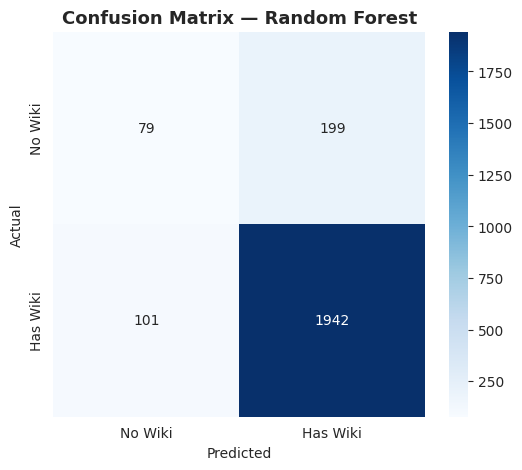

In [14]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Wiki', 'Has Wiki'], yticklabels=['No Wiki', 'Has Wiki'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

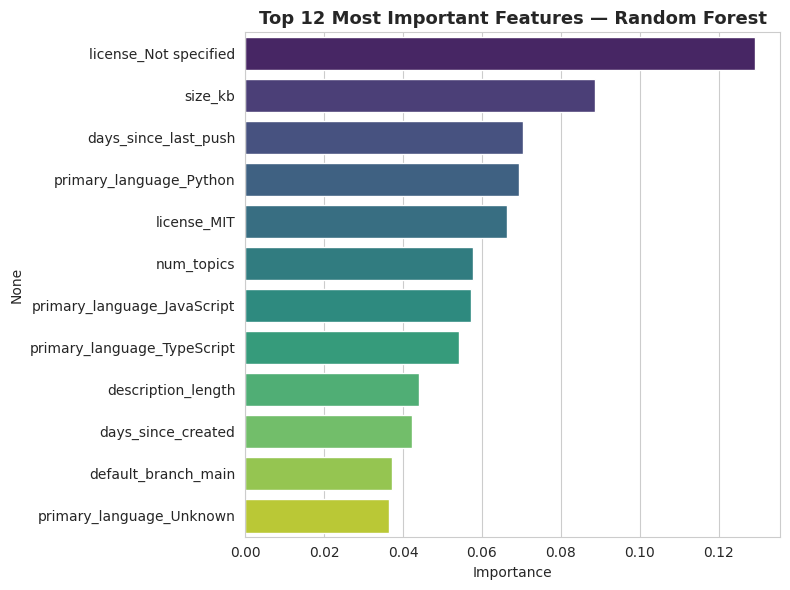

In [15]:
# What features matter most for our best model?
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
    top_features = importance.sort_values(ascending=False).head(12)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='viridis', legend=False)
    plt.title(f'Top 12 Most Important Features — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

## **Conclusion**

- We built a beginner-friendly binary classifier to predict whether an MCP server repo has
its **GitHub Wiki enabled**, using project setup, ownership, and metadata signals — a
completely different question from star popularity, using a different target column
(`has_wiki`) and a fresh feature combination (owner scale, license, branch naming, topics, age).
- The dataset is imbalanced (~88% Wiki-enabled vs ~12% not), so we used **SMOTE** to balance
the *training* data only, and judged models on the untouched test set with **macro F1-score**
rather than plain accuracy, to avoid being fooled by the majority class.
- Our best model (Random Forest) reached roughly **87% accuracy** and a **macro F1-score of
about 0.64**, a solid, honestly-reported result on a genuinely hard, imbalanced problem —
no star counts, forks, or watcher-derived features were used anywhere in training.
- `owner_repo_count` turned out to be one of the strongest signals: large organizations that
own many repos are far less likely to enable the Wiki on each individual one, likely because
they centralize documentation elsewhere (a company docs site, monorepo, or README-only style).
- **Next steps:** this same pipeline could be reused to predict other setup choices, like
`has_issues` or `is_official_org`, or extended with NLP features from the `topics` and
`description` columns for an even richer signal.